In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from collections import Counter
import random
from sklearn.metrics import f1_score


In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES  = 100
EPOCHS       = 50
BATCH_SIZE   = 128
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4

# Imbalance: class i gets int(5000 * imbalance_ratio^i) samples (exponential decay)
IMBALANCE_RATIO = 0.01   # ratio of minority to majority class
print(f"Device: {DEVICE}")


Device: cuda


In [4]:
def make_imbalanced_cifar100(imbalance_ratio=0.01, seed=42):
    """
    Creates an imbalanced CIFAR-100 training set with an exponential
    long-tail distribution. Class 0 keeps all 500 samples; class i
    gets max(int(500 * imbalance_ratio^(i/99)), 1) samples.
    The test set is left balanced.
    """
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408),
                             (0.2675, 0.2565, 0.2761)),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408),
                             (0.2675, 0.2565, 0.2761)),
    ])

    full_train = torchvision.datasets.CIFAR100(
        root='./data', train=True, download=True, transform=transform_train)
    test_set   = torchvision.datasets.CIFAR100(
        root='./data', train=False, download=True, transform=transform_test)

    # Build per-class index lists
    rng = np.random.default_rng(seed)
    targets = np.array(full_train.targets)
    max_samples = 500  # CIFAR-100 has 500 per class

    selected_indices = []
    class_counts = []
    for c in range(NUM_CLASSES):
        n_c = max(int(max_samples * (imbalance_ratio ** (c / (NUM_CLASSES - 1)))), 1)
        class_counts.append(n_c)
        idx_c = np.where(targets == c)[0]
        chosen = rng.choice(idx_c, size=n_c, replace=False)
        selected_indices.extend(chosen.tolist())

    print("Class distribution in imbalanced training set:")
    for c, n in enumerate(class_counts):
        bar = "█" * (n // 5)
        print(f"  Class {c}: {n:4d} samples  {bar}")

    imbalanced_train = Subset(full_train, selected_indices)
    return imbalanced_train, test_set, class_counts


In [5]:
train_set, test_set, class_counts = make_imbalanced_cifar100(IMBALANCE_RATIO)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nTotal training samples: {len(train_set)}")
print(f"Total test samples:     {len(test_set)}")


100%|██████████| 169M/169M [00:01<00:00, 106MB/s]  


Class distribution in imbalanced training set:
  Class 0:  500 samples  ████████████████████████████████████████████████████████████████████████████████████████████████████
  Class 1:  477 samples  ███████████████████████████████████████████████████████████████████████████████████████████████
  Class 2:  455 samples  ███████████████████████████████████████████████████████████████████████████████████████████
  Class 3:  434 samples  ██████████████████████████████████████████████████████████████████████████████████████
  Class 4:  415 samples  ███████████████████████████████████████████████████████████████████████████████████
  Class 5:  396 samples  ███████████████████████████████████████████████████████████████████████████████
  Class 6:  378 samples  ███████████████████████████████████████████████████████████████████████████
  Class 7:  361 samples  ████████████████████████████████████████████████████████████████████████
  Class 8:  344 samples  ███████████████████████████████████████

In [6]:
class ResNet18Penultimate(nn.Module):
    """
    Thin wrapper around torchvision ResNet-18 that exposes:
      - self.backbone  : everything up to (but not including) the final fc
      - self.fc        : the linear classifier head  [512 → C]
    We need this split to compute relative flatness on the penultimate layer.
    """
    def __init__(self, num_classes=100):
        super().__init__()
        base = torchvision.models.resnet18(weights=None)
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        self.backbone = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
        )
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x, return_features=False):
        h = self.backbone(x)
        h = torch.flatten(h, 1)
        logits = self.fc(h)
        if return_features:
            return logits, h
        return logits
model = ResNet18Penultimate(num_classes=NUM_CLASSES).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters()):,}")


ResNet18Penultimate(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Identity()
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2)

In [7]:
@torch.no_grad()
def compute_relative_flatness(model, loader, device, max_batches=20):
    model.eval()
    trace_sum = 0.0
    n_samples  = 0

    for batch_idx, (x, _) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        x = x.to(device)
        logits, h = model(x, return_features=True)

        p = torch.softmax(logits, dim=1)
        h_sq_norm  = (h ** 2).sum(dim=1)
        p_sq_norm  = (p ** 2).sum(dim=1)

        trace_sum += (h_sq_norm * (1.0 - p_sq_norm)).sum().item()
        n_samples  += x.size(0)

    mean_trace = trace_sum / n_samples

    W = model.fc.weight
    w_norm_sq = (W ** 2).sum().item()

    rf = mean_trace / (w_norm_sq + 1e-12)
    return rf, mean_trace, w_norm_sq


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += logits.argmax(1).eq(y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    class_correct = torch.zeros(NUM_CLASSES)
    class_total   = torch.zeros(NUM_CLASSES)

    all_preds = []
    all_targets = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss   = criterion(logits, y)
        preds  = logits.argmax(1)

        total_loss += loss.item() * x.size(0)
        correct    += preds.eq(y).sum().item()
        total      += x.size(0)

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

        for c in range(NUM_CLASSES):
            mask = y.eq(c)
            class_correct[c] += preds[mask].eq(y[mask]).sum().item()
            class_total[c]   += mask.sum().item()

    per_class_acc = (class_correct / class_total.clamp(min=1)).numpy()

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return (
        total_loss / total,
        correct / total,
        per_class_acc,
        macro_f1,
        weighted_f1
    )


In [9]:
# ── Model, loss, optimiser ────────────────────────────────────────────────────
model_exp1   = ResNet18Penultimate(num_classes=NUM_CLASSES).to(DEVICE)
criterion    = nn.CrossEntropyLoss()
optimizer    = optim.SGD(model_exp1.parameters(), lr=LR,
                         momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'rf':         [],
    'macro_f1':   [],
    'weighted_f1': []
}

print("=" * 65)
print("Experiment 1 — Baseline: CE loss | Imbalanced CIFAR-100")
print("=" * 65)


for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_one_epoch(
        model_exp1, train_loader, criterion, optimizer, DEVICE
    )

    va_loss, va_acc, per_cls, macro_f1, weighted_f1 = evaluate(
        model_exp1, test_loader, criterion, DEVICE
    )

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['macro_f1'].append(macro_f1)
    history['weighted_f1'].append(weighted_f1)

    if epoch % 5 == 0 or epoch == 1:
        rf, _, _ = compute_relative_flatness(
            model_exp1, train_loader, DEVICE, max_batches=20
        )
        history['rf'].append((epoch, rf))

        print(
            f"Ep {epoch:3d}/{EPOCHS} | "
            f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
            f"Val loss={va_loss:.4f} acc={va_acc:.3f} | "
            f"Macro-F1={macro_f1:.3f} | "
            f"Weighted-F1={weighted_f1:.3f} | "
            f"RF={rf:.4f}"
        )


Experiment 1 — Baseline: CE loss | Imbalanced CIFAR-100
Ep   1/50 | Train loss=3.9496 acc=0.104 | Val loss=5.0134 acc=0.055 | Macro-F1=0.020 | Weighted-F1=0.020 | RF=0.7015
Ep   5/50 | Train loss=2.9903 acc=0.266 | Val loss=4.6469 acc=0.105 | Macro-F1=0.057 | Weighted-F1=0.057 | RF=0.3555
Ep  10/50 | Train loss=2.2781 acc=0.414 | Val loss=4.2595 acc=0.168 | Macro-F1=0.113 | Weighted-F1=0.113 | RF=0.2357
Ep  15/50 | Train loss=1.6418 acc=0.550 | Val loss=3.6993 acc=0.245 | Macro-F1=0.203 | Weighted-F1=0.203 | RF=0.1722
Ep  20/50 | Train loss=1.1740 acc=0.669 | Val loss=3.5738 acc=0.282 | Macro-F1=0.240 | Weighted-F1=0.240 | RF=0.1308
Ep  25/50 | Train loss=0.7356 acc=0.781 | Val loss=3.4068 acc=0.320 | Macro-F1=0.279 | Weighted-F1=0.279 | RF=0.1069
Ep  30/50 | Train loss=0.3621 acc=0.895 | Val loss=3.3352 acc=0.355 | Macro-F1=0.314 | Weighted-F1=0.314 | RF=0.0701
Ep  35/50 | Train loss=0.1096 acc=0.978 | Val loss=3.1484 acc=0.387 | Macro-F1=0.346 | Weighted-F1=0.346 | RF=0.0335
Ep  40/5

In [10]:
_, final_val_acc, final_per_cls, final_macro_f1, final_weighted_f1 = evaluate(
    model_exp1, test_loader, criterion, DEVICE
)

final_rf, _, _ = compute_relative_flatness(
    model_exp1, train_loader, DEVICE, max_batches=None
)

print("\n── Final Results ──────────────────────────────────────────")
print(f"Overall test accuracy : {final_val_acc:.4f}")
print(f"Macro F1 score        : {final_macro_f1:.4f}")
print(f"Weighted F1 score     : {final_weighted_f1:.4f}")
print(f"Relative Flatness (RF): {final_rf:.6f}")

print("\nPer-class test accuracy:")
for c, acc in enumerate(final_per_cls):
    n_train = class_counts[c]
    bar = "█" * int(acc * 20)
    print(f"  Class {c} (n={n_train:4d}): {acc:.3f}  {bar}")



── Final Results ──────────────────────────────────────────
Overall test accuracy : 0.3942
Macro F1 score        : 0.3547
Weighted F1 score     : 0.3547
Relative Flatness (RF): 0.012349

Per-class test accuracy:
  Class 0 (n= 500): 0.940  ██████████████████
  Class 1 (n= 477): 0.860  █████████████████
  Class 2 (n= 455): 0.700  ██████████████
  Class 3 (n= 434): 0.650  █████████████
  Class 4 (n= 415): 0.640  ████████████
  Class 5 (n= 396): 0.790  ███████████████
  Class 6 (n= 378): 0.800  ████████████████
  Class 7 (n= 361): 0.760  ███████████████
  Class 8 (n= 344): 0.860  █████████████████
  Class 9 (n= 328): 0.800  ████████████████
  Class 10 (n= 314): 0.590  ███████████
  Class 11 (n= 299): 0.550  ███████████
  Class 12 (n= 286): 0.830  ████████████████
  Class 13 (n= 273): 0.780  ███████████████
  Class 14 (n= 260): 0.540  ██████████
  Class 15 (n= 248): 0.700  ██████████████
  Class 16 (n= 237): 0.710  ██████████████
  Class 17 (n= 226): 0.810  ████████████████
  Class 18 (n= 

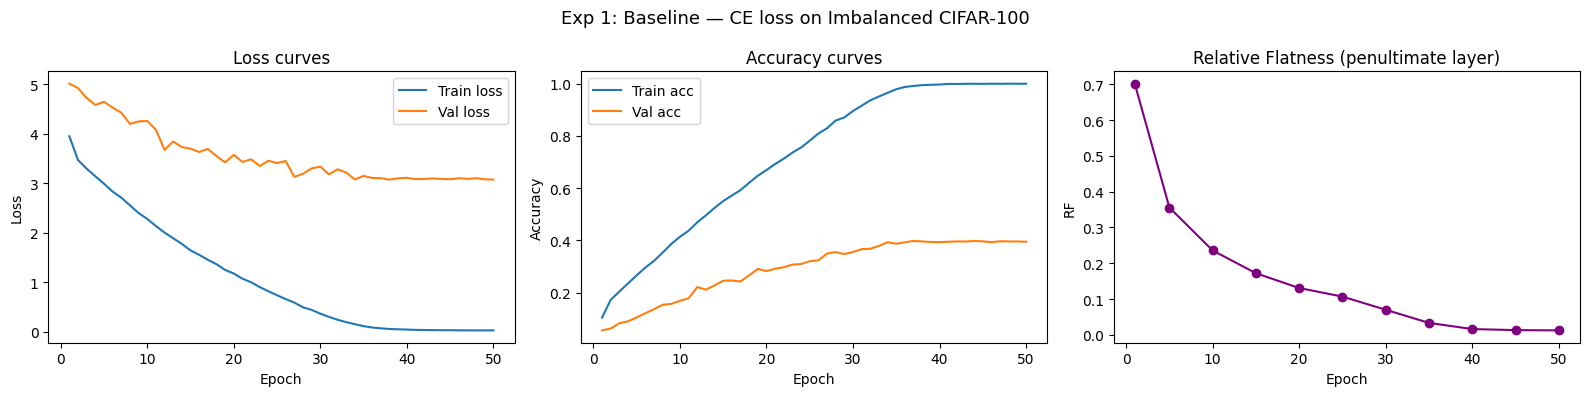

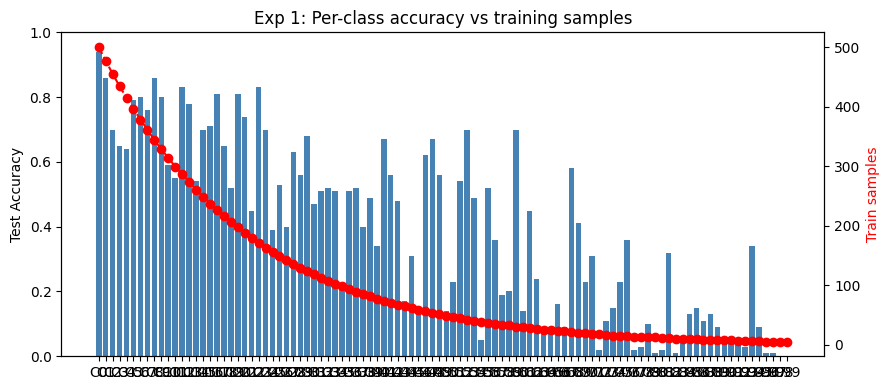

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Exp 1: Baseline — CE loss on Imbalanced CIFAR-100", fontsize=13)

epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history['train_loss'], label='Train loss')
axes[0].plot(epochs_x, history['val_loss'],   label='Val loss')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss curves"); axes[0].legend()

axes[1].plot(epochs_x, history['train_acc'], label='Train acc')
axes[1].plot(epochs_x, history['val_acc'],   label='Val acc')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy curves"); axes[1].legend()

rf_epochs, rf_vals = zip(*history['rf'])
axes[2].plot(rf_epochs, rf_vals, marker='o', color='purple')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("RF")
axes[2].set_title("Relative Flatness (penultimate layer)")

plt.tight_layout()
plt.savefig("exp1_baseline.png", dpi=150)
plt.show()


fig2, ax = plt.subplots(figsize=(9, 4))
x = np.arange(NUM_CLASSES)
bars = ax.bar(x, final_per_cls, color='steelblue')
ax2 = ax.twinx()
ax2.plot(x, class_counts, 'r--o')
ax2.set_ylabel("Train samples", color='red')
ax.set_xticks(x)
ax.set_xticklabels([f"C{i}" for i in range(NUM_CLASSES)])
ax.set_ylabel("Test Accuracy"); ax.set_ylim(0, 1)
ax.set_title("Exp 1: Per-class accuracy vs training samples")
plt.tight_layout()
plt.savefig("exp1_perclass.png", dpi=150)
plt.show()